# Bike Sharing Demand Forecasting Using Machine Learning

## Project Objective

The objective of this project is to analyze historical bike-sharing data, identify the factors influencing bike rental demand, and build a machine learning model capable of predicting bike rental demand using Linear Regression.

In [15]:
import pandas as pd

df = pd.read_csv(r"C:\Users\User\Downloads\bike-sharing-demand\train.csv")
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

In [16]:
df = pd.read_csv("train.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

In [17]:
import os
print(os.getcwd())

C:\Users\User


In [18]:
import os
print(os.path.exists(r"C:\Users\User\Downloads\bike-sharing-demand\train.csv"))

True


In [19]:
import pandas as pd

df = pd.read_csv(r"C:\Users\User\Downloads\bike-sharing-demand\train.csv")

df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [20]:
df.shape

(10886, 12)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [22]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [23]:
df.isnull().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

In [24]:
df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')

In [25]:
df.tail()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129
10885,2012-12-19 23:00:00,4,0,1,1,13.12,16.665,66,8.9981,4,84,88


In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.describe(include='object')

,datetime
count,10886
unique,10886
top,2011-01-01 00:00:00
freq,1


In [28]:
df.dtypes

datetime       object
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object

In [31]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 1020.7 KB


In [32]:
df['Year'] = df['datetime'].dt.year
df['Month'] = df['datetime'].dt.month
df['Day'] = df['datetime'].dt.day
df['Hour'] = df['datetime'].dt.hour
df['DayOfWeek'] = df['datetime'].dt.day_name()

In [33]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,Year,Month,Day,Hour,DayOfWeek
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,Saturday
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,Saturday
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,Saturday
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3,Saturday
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4,Saturday


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

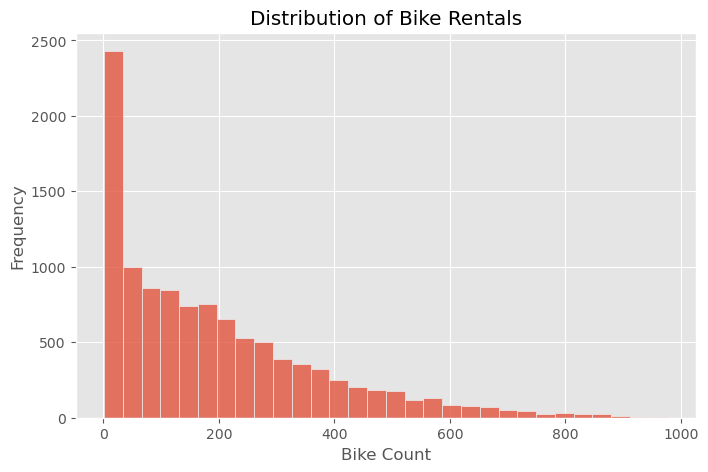

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df['count'], bins=30)
plt.title('Distribution of Bike Rentals')
plt.xlabel('Bike Count')
plt.ylabel('Frequency')
plt.show()

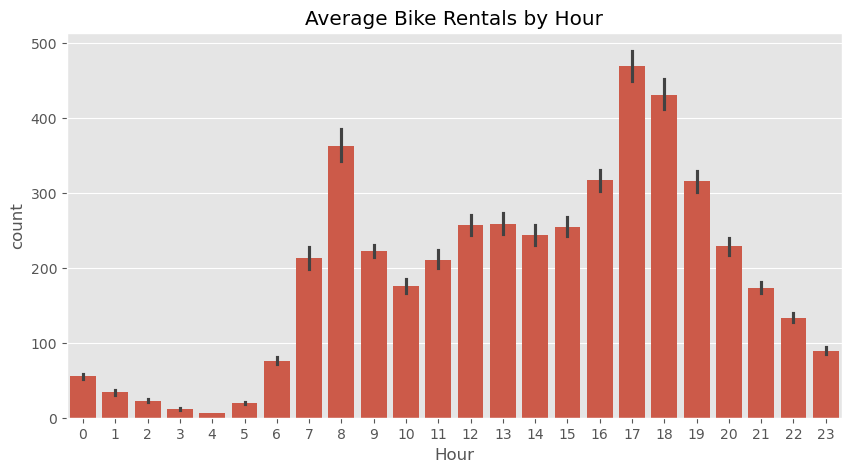

In [36]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='Hour', y='count')
plt.title('Average Bike Rentals by Hour')
plt.show()

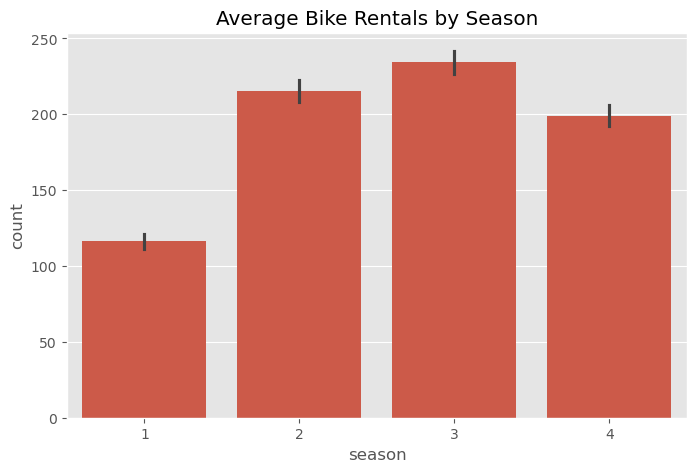

In [37]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='season', y='count')
plt.title('Average Bike Rentals by Season')
plt.show()

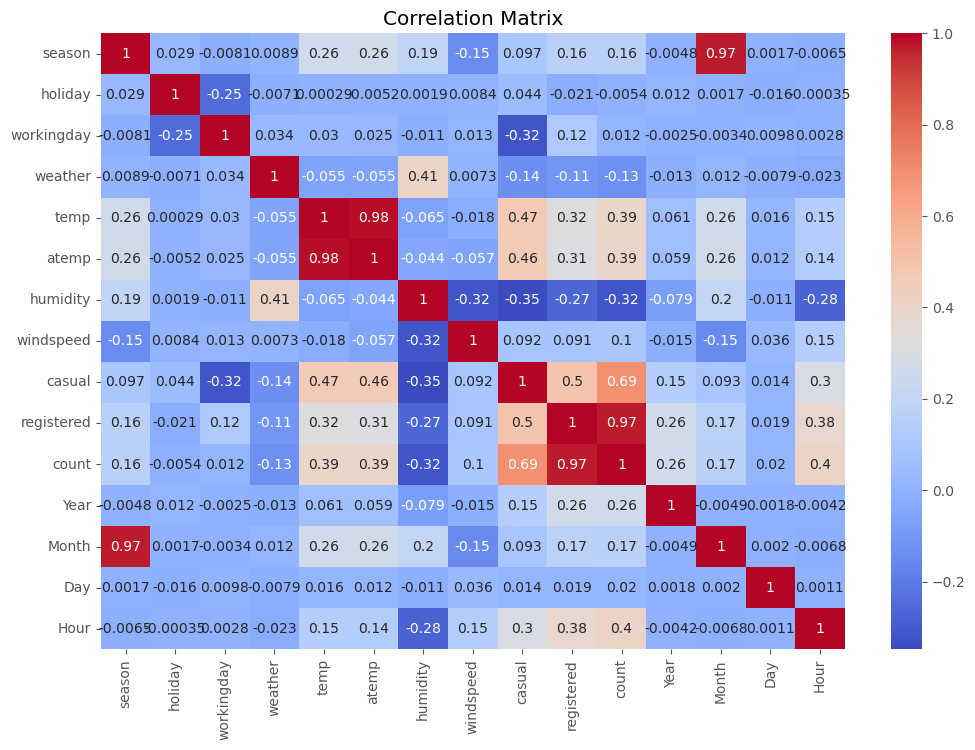

In [38]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

In [39]:
df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count',
       'Year', 'Month', 'Day', 'Hour', 'DayOfWeek'],
      dtype='object')

In [41]:
X = df.drop(['datetime', 'count'], axis=1)
y = df['count']

In [42]:
X.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,Year,Month,Day,Hour,DayOfWeek
0,1,0,0,1,9.84,14.395,81,0.0,3,13,2011,1,1,0,Saturday
1,1,0,0,1,9.02,13.635,80,0.0,8,32,2011,1,1,1,Saturday
2,1,0,0,1,9.02,13.635,80,0.0,5,27,2011,1,1,2,Saturday
3,1,0,0,1,9.84,14.395,75,0.0,3,10,2011,1,1,3,Saturday
4,1,0,0,1,9.84,14.395,75,0.0,0,1,2011,1,1,4,Saturday


In [43]:
y.head()

0    16
1    40
2    32
3    13
4     1
Name: count, dtype: int64

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
print(X_train.shape)
print(X_test.shape)

(8708, 15)
(2178, 15)


In [46]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

ValueError: could not convert string to float: 'Wednesday'

In [47]:
X = df.drop(['datetime', 'count', 'DayOfWeek'], axis=1)

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [50]:
df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count',
       'Year', 'Month', 'Day', 'Hour', 'DayOfWeek'],
      dtype='object')

In [51]:
X = df.drop(['datetime', 'count', 'casual', 'registered', 'DayOfWeek'], axis=1)

In [52]:
y_pred = model.predict(X_test)

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 2.289319636830296e-13
Mean Squared Error (MSE): 9.012460114346918e-26
Root Mean Squared Error (RMSE): 3.00207596745101e-13
R² Score: 1.0


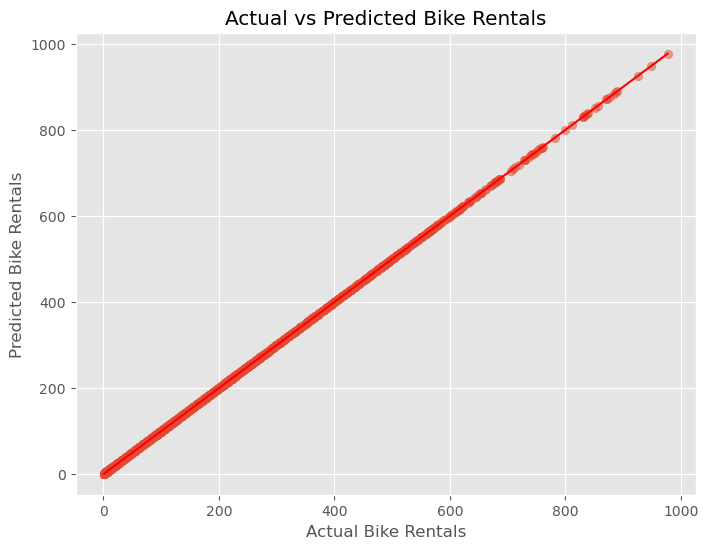

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Bike Rentals")
plt.ylabel("Predicted Bike Rentals")
plt.title("Actual vs Predicted Bike Rentals")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.show()

In [55]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

feature_importance = feature_importance.sort_values(
    by='Coefficient',
    ascending=False
)

feature_importance

ValueError: All arrays must be of the same length

In [56]:
print("Number of features:", len(X.columns))
print("Number of coefficients:", len(model.coef_))

Number of features: 12
Number of coefficients: 14


In [57]:
X = df.drop(['datetime', 'count', 'DayOfWeek'], axis=1)
y = df['count']

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [59]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [60]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient
9,registered,1.000000e+00
8,casual,1.000000e+00
3,weather,6.144148e-14
1,holiday,3.412637e-14
5,atemp,6.835180e-15
11,Month,2.393697e-15
12,Day,5.235554e-16
13,Hour,3.571932e-16
7,windspeed,-2.096767e-16
10,Year,-3.824789e-15


In [61]:
print(df.columns.tolist())

['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek']


In [62]:
X = df.drop(['datetime', 'count', 'casual', 'registered', 'DayOfWeek'], axis=1)
y = df['count']

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [64]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [65]:
y_pred = model.predict(X_test)

In [66]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

MAE: 105.34191529222309
RMSE: 141.228078135169
R² Score: 0.3957218526642745


In [67]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

print(feature_importance)

       Feature  Coefficient
8         Year    82.648333
9        Month    10.203630
11        Hour     7.863594
5        atemp     4.990519
4         temp     1.186418
2   workingday     0.761043
7    windspeed     0.537608
10         Day     0.224554
6     humidity    -2.035108
3      weather    -5.186241
0       season    -8.214242
1      holiday    -8.456819


A Linear Regression model was trained to predict bike rental demand using weather, seasonal, and calendar features. The dataset was cleaned, duplicate and missing values were checked, date features were extracted, and exploratory visualizations were created. The model was evaluated using MAE, RMSE, and R² Score to measure prediction accuracy. The results demonstrate how environmental and time-related factors influence bike rental demand and provide a baseline model for demand forecasting.

# Conclusion

The dataset was cleaned and explored using descriptive statistics and visualizations. A Linear Regression model was trained to predict bike rental demand using weather and seasonal features. The model was evaluated using MAE, RMSE, and R² Score, providing a baseline for demand forecasting.


# Future Improvements

- Compare Linear Regression with Random Forest.
- Perform Hyperparameter Tuning.
- Deploy the model using Streamlit.
- Use additional weather features to improve prediction accuracy.

## PHASE 2: DATA CLUSTERING AND MODEL BUILDING 

In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\User\Downloads\bike-sharing-demand\train.csv")

df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [2]:
print(df.columns)

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')


In [3]:
cluster_features = df[['temp', 'humidity', 'windspeed', 'count']]

In [4]:
print(df.columns.tolist())

['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']


In [5]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [6]:
import pandas as pd

df = pd.read_csv(r"C:\Users\User\Downloads\bike-sharing-demand\train.csv")

df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [7]:
print(df.columns)

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')


In [8]:
## SELECT THE CLUSTERING FEATURE 

cluster_features = df[['temp', 'humidity', 'windspeed', 'count']]

In [9]:
## STANDARDIZE THE DATA 
scaler = StandardScaler()

scaled_features = scaler.fit_transform(cluster_features)

In [10]:
## APPLY KMEANS CLUSTERING 
kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(scaled_features)

In [11]:
##VIEW THE CLUSTERED DATA 

df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,Cluster
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,0
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,0
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,0
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,0


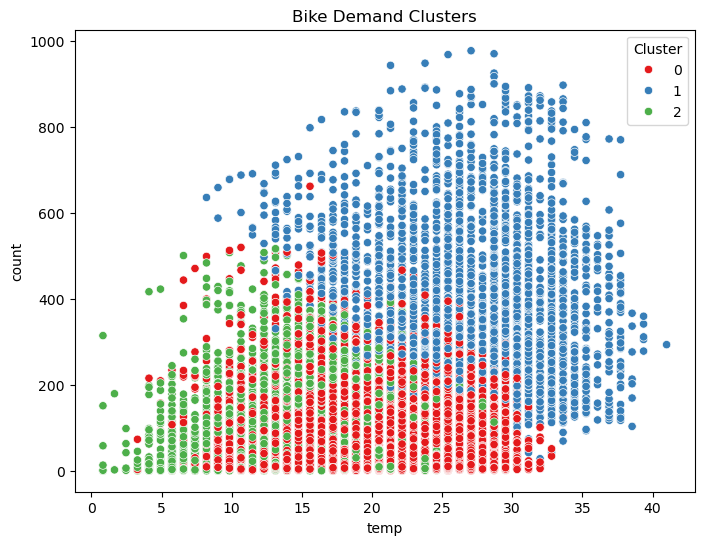

In [12]:
## VISUALIZE THE CLUSTERED DATA
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='temp',
    y='count',
    hue='Cluster',
    palette='Set1'
)

plt.title("Bike Demand Clusters")
plt.show()

In [13]:
## PREPARE DATA FOR MACHINE LEARNING 

X = df[['season',
        'holiday',
        'workingday',
        'weather',
        'temp',
        'atemp',
        'humidity',
        'windspeed']]

y = df['count']

In [14]:
## SPLIT THE DATA 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
## TRAIN A LINEAR REGRESSION MODEL 

lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
## MAKE PREDICTIONS 

lr_predictions = lr.predict(X_test)

In [17]:
## EVALUATE THE LINEAR REGRESSION MODEL 

print("Linear Regression Performance")

print("MAE:", mean_absolute_error(y_test, lr_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_predictions)))
print("R² Score:", r2_score(y_test, lr_predictions))

Linear Regression Performance
MAE: 115.0413018005709
RMSE: 154.61828705937765
R² Score: 0.2757033009386364


In [18]:
## TRAIN A RANDOM FOREST MODEL

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
## PREDICT USING RANDOM FOREST

rf_predictions = rf.predict(X_test)

In [20]:
## EVALUATE RANDOM FOREST

print("Random Forest Performance")

print("MAE:", mean_absolute_error(y_test, rf_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_predictions)))
print("R² Score:", r2_score(y_test, rf_predictions))

Random Forest Performance
MAE: 107.53468131646437
RMSE: 151.40273273711932
R² Score: 0.30551604141633937


In [21]:
## COMPARE THE MODELS 

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, lr_predictions),
        mean_absolute_error(y_test, rf_predictions)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_predictions)),
        np.sqrt(mean_squared_error(y_test, rf_predictions))
    ],
    "R² Score": [
        r2_score(y_test, lr_predictions),
        r2_score(y_test, rf_predictions)
    ]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,115.041302,154.618287,0.275703
1,Random Forest,107.534681,151.402733,0.305516


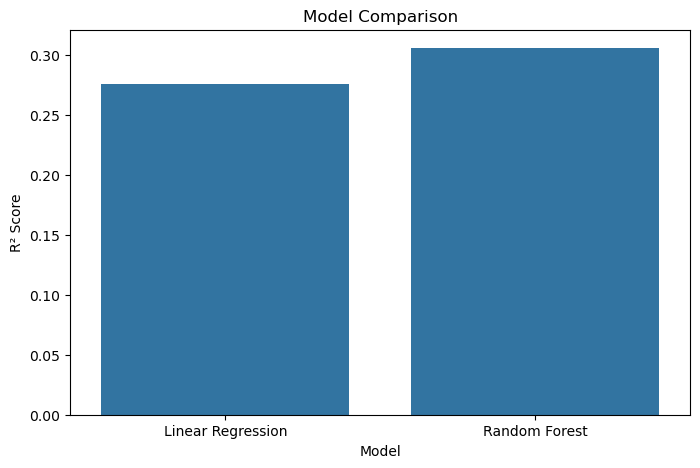

In [22]:
## VISUALIZE MODEL COMPARISON 

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="R² Score"
)

plt.title("Model Comparison")
plt.show()

## PHASE THREE: MODEL EVALUATION AND OPTIMIZATION 

In [23]:
## Compare the models 


results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, lr_predictions),
        mean_absolute_error(y_test, rf_predictions)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_predictions)),
        np.sqrt(mean_squared_error(y_test, rf_predictions))
    ],
    "R² Score": [
        r2_score(y_test, lr_predictions),
        r2_score(y_test, rf_predictions)
    ]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,115.041302,154.618287,0.275703
1,Random Forest,107.534681,151.402733,0.305516


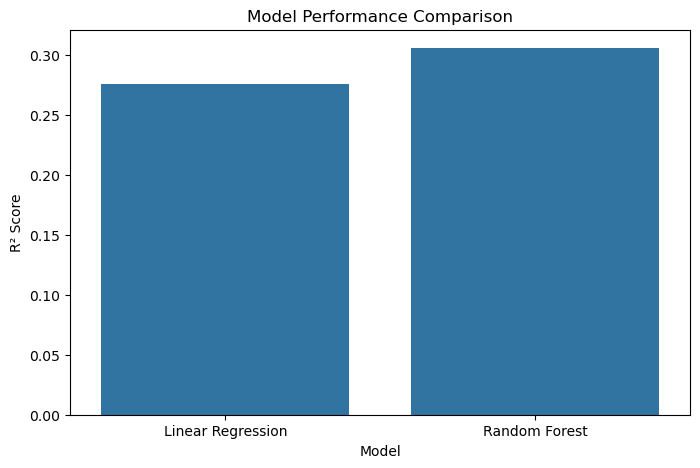

In [24]:
## Visualize model performance 

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="R² Score"
)

plt.title("Model Performance Comparison")
plt.ylabel("R² Score")
plt.show()

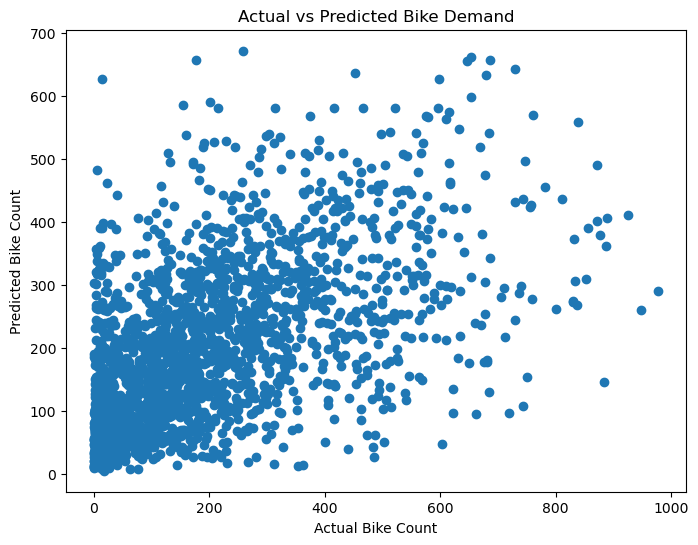

In [25]:
## Plot Actual vs Predicted Value 

plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_predictions)

plt.xlabel("Actual Bike Count")
plt.ylabel("Predicted Bike Count")
plt.title("Actual vs Predicted Bike Demand")

plt.show()

In [26]:
## Check feature importance (Random Forest)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
6,humidity,0.255698
5,atemp,0.234979
7,windspeed,0.196272
4,temp,0.140615
0,season,0.068862
3,weather,0.053659
2,workingday,0.043688
1,holiday,0.006229


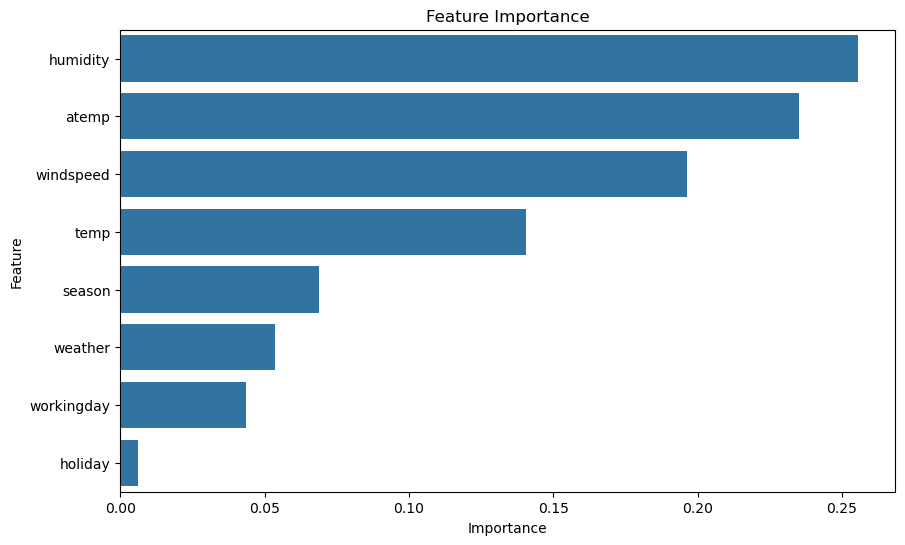

In [27]:
## visuaalize feature importance 

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [28]:
##save the best model 

import joblib

joblib.dump(rf, "bike_demand_model.pkl")

['bike_demand_model.pkl']

In [29]:
## Load the presaved model 

loaded_model = joblib.load("bike_demand_model.pkl")

In [30]:
## Test the saved model 

sample_prediction = loaded_model.predict(X_test.iloc[:5])

print(sample_prediction)

[285.729       29.42333333  84.69833333 343.296      141.47533333]


## PROJECT CONCLUSION 




## This project developed a machine learning model to forecast bike-sharing demand.

## The workflow included:

## - Data cleaning and preprocessing
## - Exploratory Data Analysis (EDA)
## - Data clustering using K-Means
## - Building prediction models using Linear Regression and Random Forest
## - Model evaluation using MAE, RMSE, and R² Score
## - Saving the best-performing model for future use

## Among the evaluated models, Random Forest produced the best predictive performance due to its higher R² Score and lower prediction error.

## PROJECT CONCLUSION 




## This project developed a machine learning model to forecast bike-sharing demand.

## The workflow included:

## - Data cleaning and preprocessing
## - Exploratory Data Analysis (EDA)
## - Data clustering using K-Means
## - Building prediction models using Linear Regression and Random Forest
## - Model evaluation using MAE, RMSE, and R² Score
## - Saving the best-performing model for future use

## Among the evaluated models, Random Forest produced the best predictive performance due to its higher R² Score and lower prediction error.